In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#df=pd.read_csv("customer.csv")
#df.head()
print(df.columns)
# To show plots
#%matplotlib inline

Index(['customer_id', 'Name', 'Age', 'Gender', 'City'], dtype='str')


In [5]:
df = pd.read_csv("customer.csv")
df

,customer_id,Name,Age,Gender,City
0,C001,Ravi,25,Male,Hyderabad
1,C002,Priya,30,Female,Vijayawada
2,C003,Arjun,22,Male,visakhapatnam
3,C004,Sneha,28,Female,Guntur
4,C005,Kiran,35,Male,Tirupati


PHASE-1 Data inspection and structural diagnosis

In [6]:
#data shape
df.shape

(5, 5)

In [7]:
#dataset info
df.info

<bound method DataFrame.info of   customer_id   Name  Age  Gender           City
0        C001   Ravi   25    Male      Hyderabad
1        C002  Priya   30  Female     Vijayawada
2        C003  Arjun   22    Male  visakhapatnam
3        C004  Sneha   28  Female         Guntur
4        C005  Kiran   35    Male       Tirupati>

In [8]:
#describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5.0,28.0,4.949747,22.0,25.0,28.0,30.0,35.0


In [15]:
#datatypes
df.dtypes

customer_id      str
Name             str
Age            int64
Gender           str
City             str
dtype: object

PHASE-2 Rigorous Data Cleaning

In [16]:
#duplicate check
df.duplicated().sum()

np.int64(0)

In [17]:
#Remove duplicates
df=df.drop_duplicates()

In [21]:
#missing values before cleaning
df.isnull().sum()

customer_id    0
Name           0
Age            0
Gender         0
City           0
dtype: int64

In [27]:
#convert wrong datatypes
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df.head()

,customer_id,Name,Age,Gender,City
0,C001,Ravi,25,Male,Hyderabad
1,C002,Priya,30,Female,Vijayawada
2,C003,Arjun,22,Male,visakhapatnam
3,C004,Sneha,28,Female,Guntur
4,C005,Kiran,35,Male,Tirupati


In [34]:
#Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)
df.isnull().sum()

customer_id    0
Name           0
Age            0
Gender         0
City           0
dtype: int64

PHASE-3 Visual and Statistical Analysis

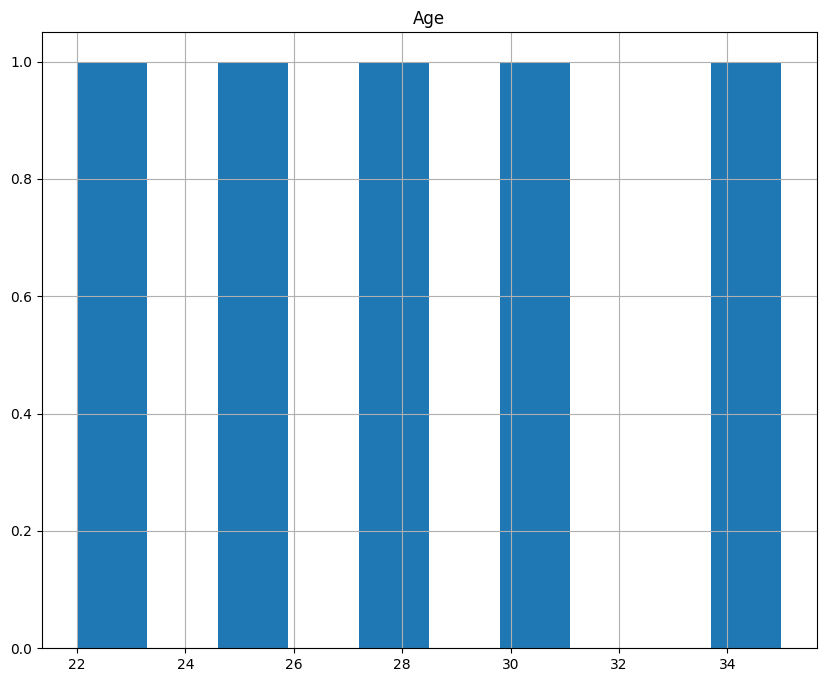

In [39]:
#histogram
import matplotlib.pyplot as plt
df.hist(figsize=(10,8))
plt.show()

In [40]:
#skewness
df.skew(numeric_only=True)

Age    0.371076
dtype: float64

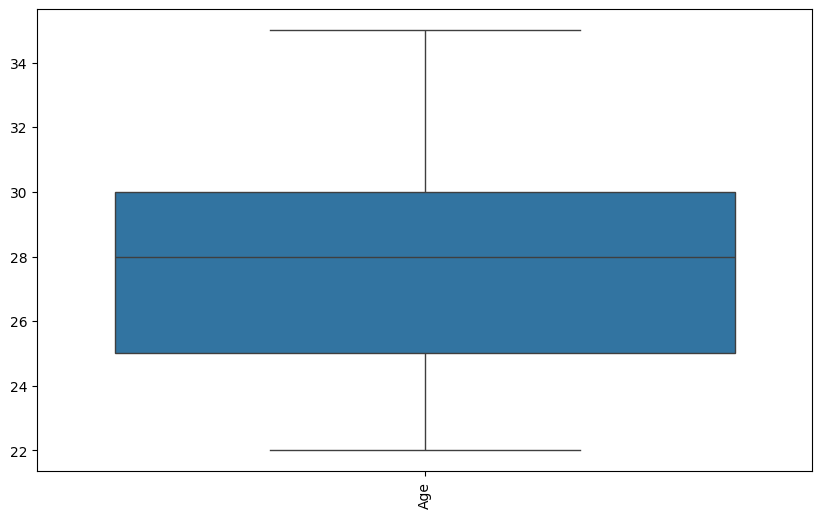

In [42]:
#boxplot outliers
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

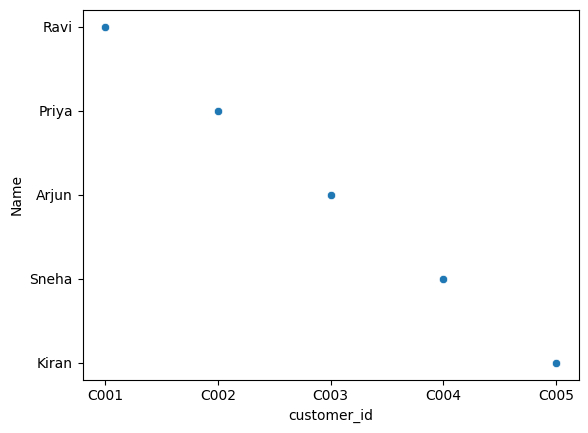

In [ ]:
#scatter plot
sns.scatterplot(x='customer_id', y='Name', data=df)
plt.show()

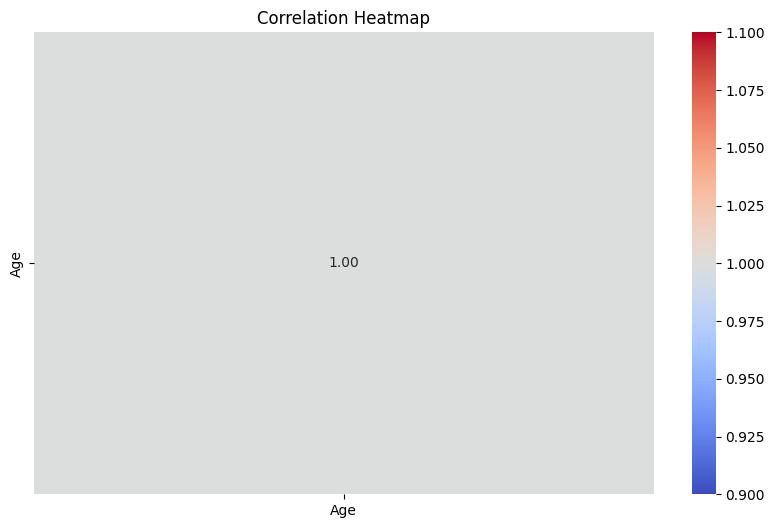

In [ ]:
#correlation heatmap
#plt.figure(figsize=(10,6))
#sns.heatmap(df.corr(numeric_only=True),
  #          annot=True,
#            cmap='coolwarm')

#plt.show()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("cleaned_dataset.csv")

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

PHASE-4 save cleaned dataset

In [49]:
df.to_csv("cleaned_dataset.csv", index=False)
df

,customer_id,Name,Age,Gender,City
0,C001,Ravi,25,Male,Hyderabad
1,C002,Priya,30,Female,Vijayawada
2,C003,Arjun,22,Male,visakhapatnam
3,C004,Sneha,28,Female,Guntur
4,C005,Kiran,35,Male,Tirupati
